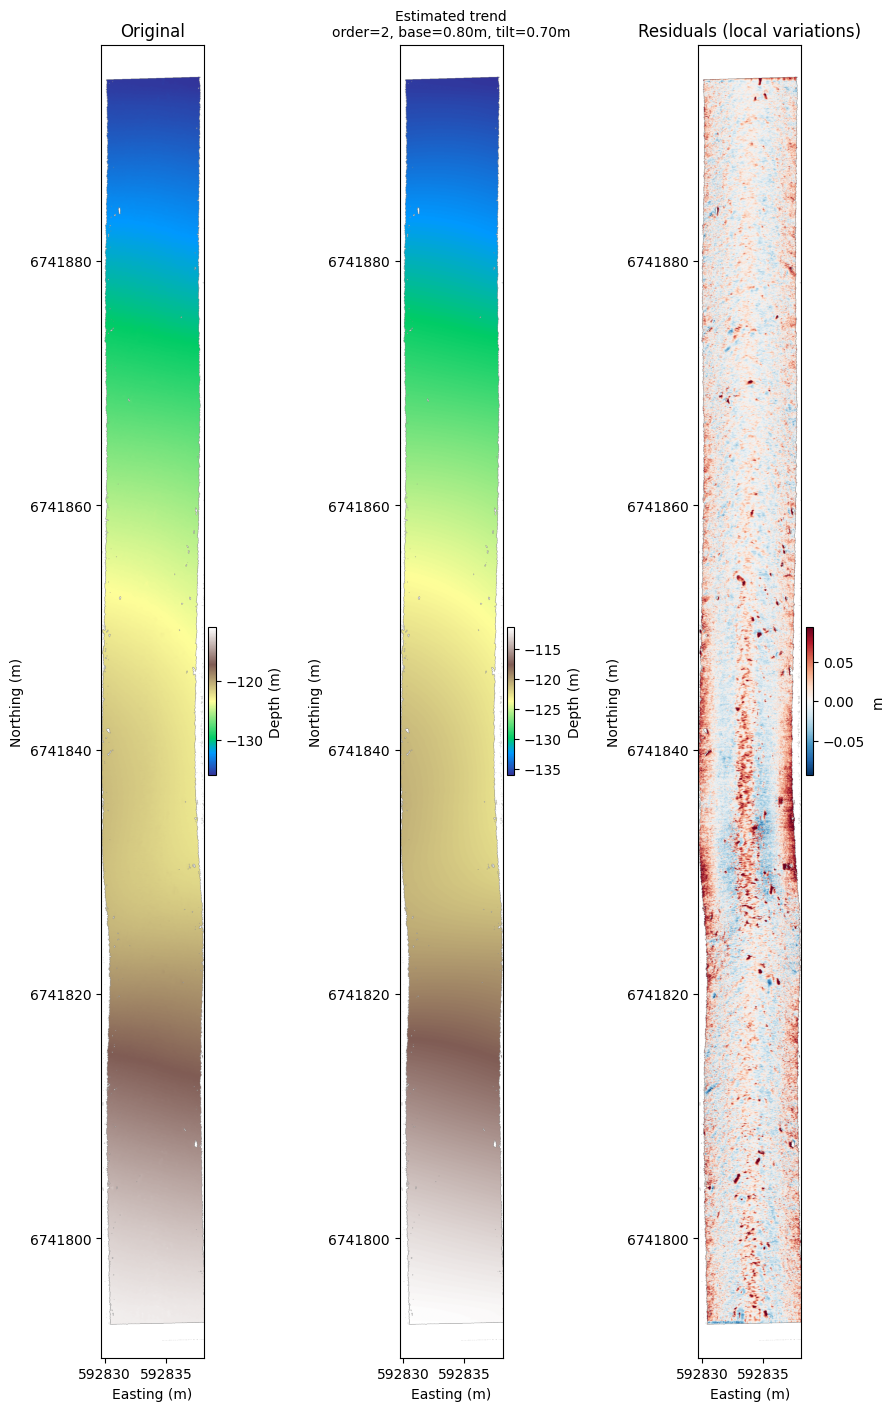

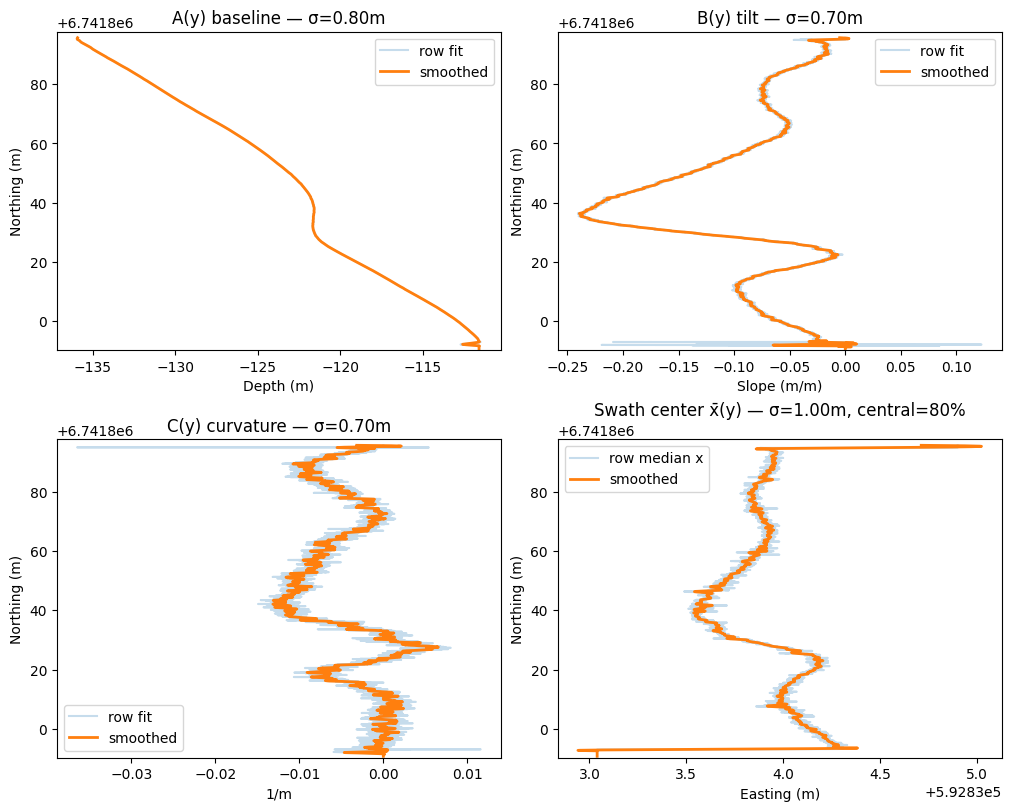

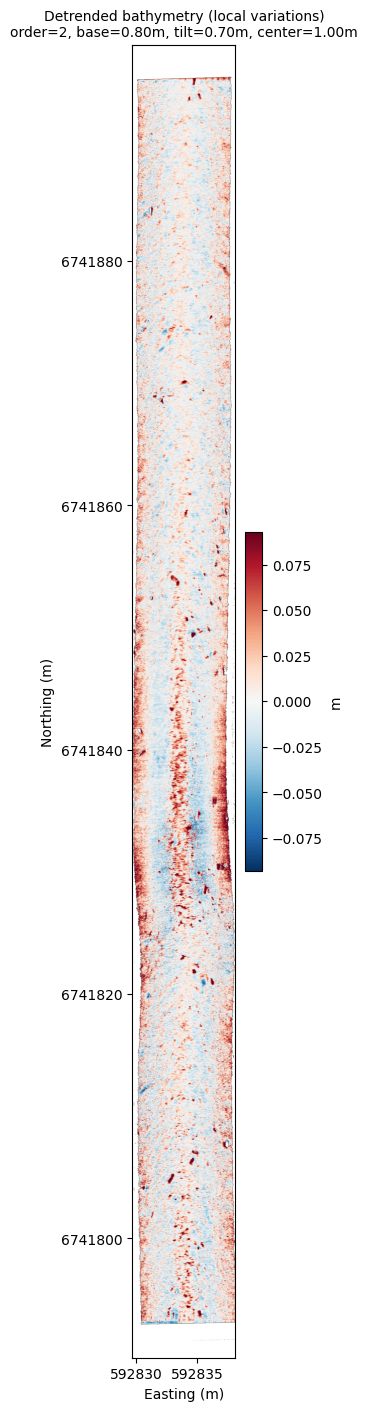

c:\conda_envs\my_env\lib\site-packages\numpy\lib\nanfunctions.py:1217: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a, func=_nanmedian, keepdims=keepdims,


… tried 5/162 in coarse grid (last score 32.8078)
… tried 10/162 in coarse grid (last score 39.9406)
… tried 15/162 in coarse grid (last score 33.1558)
… tried 20/162 in coarse grid (last score 40.2866)
… tried 25/162 in coarse grid (last score 27.9786)
… tried 30/162 in coarse grid (last score 37.3008)
… tried 35/162 in coarse grid (last score 26.3390)
… tried 40/162 in coarse grid (last score 31.2376)
… tried 45/162 in coarse grid (last score 25.6772)
… tried 50/162 in coarse grid (last score 30.4183)
… tried 55/162 in coarse grid (last score 38.4231)
… tried 60/162 in coarse grid (last score 28.8988)
… tried 65/162 in coarse grid (last score 38.4486)
… tried 70/162 in coarse grid (last score 23.0175)
… tried 75/162 in coarse grid (last score 39.1099)
… tried 80/162 in coarse grid (last score 23.4584)
… tried 85/162 in coarse grid (last score 32.8385)
… tried 90/162 in coarse grid (last score 26.6806)
… tried 95/162 in coarse grid (last score 33.1419)
… tried 100/162 in coarse grid (

MemoryError: Unable to allocate 56.4 MiB for an array with shape (5249, 1408) and data type float64

In [ ]:
# mbes_detrend_plot_fixed.py
# Standalone: pip install rasterio numpy matplotlib scipy

import numpy as np
import rasterio
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Optional, Tuple
from scipy.ndimage import gaussian_filter1d
from scipy.signal import savgol_filter
from scipy.stats import median_abs_deviation


# ---------- helpers -----------------------------------------------------------


def _pad_limits(ax, x_min, x_max, y_min, y_max, pad_frac=0.03, equal_aspect=True):
    """Pad axes limits a bit and set a data-driven aspect so tall/skinny swaths
    fill the figure instead of being squashed into a sliver."""
    xr = max(1e-12, x_max - x_min)
    yr = max(1e-12, y_max - y_min)

    ax.set_xlim(x_min - xr * pad_frac, x_max + xr * pad_frac)
    ax.set_ylim(y_min - yr * pad_frac, y_max + yr * pad_frac)

    if equal_aspect:
        # Keep meters equal AND resize the axes box to the data ratio.
        # (Prevents the “half a figure” look with very tall/skinny rasters.)
        ax.set_aspect("equal", adjustable="datalim")
        try:
            ax.set_box_aspect(yr / xr)  # Matplotlib ≥ 3.3
        except Exception:
            pass

    # Plain numeric ticks (no +6.74e6 offsets)
    try:
        ax.ticklabel_format(style="plain", axis="both", useOffset=False)
    except Exception:
        pass


def _robust_sym_vlim(arr, q=0.98):
    m = np.isfinite(arr)
    if not m.any():
        return (-1, 1)
    lo, hi = np.nanquantile(arr[m], [(1 - q) / 2, 1 - (1 - q) / 2])
    vmax = max(abs(lo), abs(hi))
    if not np.isfinite(vmax) or vmax == 0:
        vmax = (np.nanstd(arr[m]) or 1.0) * 3
    return (-vmax, vmax)


def _rows_from_meters(pix_size_y, meters, poly=2):
    n = max(5, int(round((meters or 0.0) / max(abs(pix_size_y) or 1.0, 1e-9))))
    if n % 2 == 0:
        n += 1
    if n <= poly + 2:
        n = poly + 3 if (poly + 3) % 2 == 1 else poly + 4
    return n


def _savgol_nanaware(arr, pix_size_y, meters, poly=2):
    """Savitzky–Golay smoothing that copes with NaNs; falls back to Gaussian if
    window > #valid samples."""
    a = np.asarray(arr, float)
    valid = np.isfinite(a)
    if valid.sum() < 3:
        return a.copy()

    nwin = _rows_from_meters(pix_size_y, meters, poly=poly)

    if valid.sum() < nwin:
        # Fallback: NaN-aware Gaussian via normalization
        tmp = a.copy()
        tmp[~valid] = 0.0
        w = valid.astype(float)
        sigma = max(0.5, nwin / 6)
        num = gaussian_filter1d(tmp, sigma=sigma, mode="reflect", truncate=3.5)
        den = gaussian_filter1d(w, sigma=sigma, mode="reflect", truncate=3.5)
        out = np.where(den > 1e-6, num / den, np.nan)
        out[~valid] = np.nan
        return out

    # Prefill internal gaps with linear interpolation, then SG with edge interp
    filled = a.copy()
    if (~valid).any():
        idx = np.arange(filled.size)
        filled[~valid] = np.interp(idx[~valid], idx[valid], filled[valid])
    out = savgol_filter(filled, window_length=nwin, polyorder=poly, mode="interp")
    return out


# ---------- main class --------------------------------------------------------


@dataclass
class MBESDetrender:
    tif_path: str
    nodata_value: Optional[float] = 9999.0

    # smoothing scales (meters, along-track)
    smooth_baseline_m: float = 10.0  # A(y)
    smooth_tilt_m: float = 20.0  # B(y)
    smooth_curv_m: Optional[float] = None  # C(y); defaults to tilt_m
    smooth_center_m: float = 6.0  # x̄(y)

    # robust fit options
    max_row_iters: int = 3
    clip_sigma: float = 6.0
    central_frac: float = 0.8  # use central 80% of beams

    # internals (filled by load/detrend)
    data: Optional[np.ndarray] = None
    valid_mask: Optional[np.ndarray] = None
    transform: Optional[object] = None
    extent: Optional[Tuple[float, float, float, float]] = None
    px_x: Optional[float] = None
    px_y: Optional[float] = None
    x_cols: Optional[np.ndarray] = None
    y_rows: Optional[np.ndarray] = None

    A: Optional[np.ndarray] = None
    B: Optional[np.ndarray] = None
    C: Optional[np.ndarray] = None
    A_s: Optional[np.ndarray] = None
    B_s: Optional[np.ndarray] = None
    C_s: Optional[np.ndarray] = None
    x_center_row: Optional[np.ndarray] = None
    x_center_s: Optional[np.ndarray] = None

    trend: Optional[np.ndarray] = None
    residuals: Optional[np.ndarray] = None

    # --- I/O ---
    def load(self):
        with rasterio.open(self.tif_path) as src:
            z = src.read(1).astype(np.float64)
            tf = src.transform
            b = src.bounds

        if self.nodata_value is not None:
            z = np.where(z == self.nodata_value, np.nan, z)

        self.valid_mask = np.isfinite(z)
        self.data = z
        self.transform = tf
        self.extent = (float(b.left), float(b.right), float(b.bottom), float(b.top))

        a, _, c, _, e, f = tf.a, tf.b, tf.c, tf.d, tf.e, tf.f
        H, W = z.shape
        cols = np.arange(W)
        rows = np.arange(H)
        self.x_cols = c + a * (cols + 0.5)
        self.y_rows = f + e * (rows + 0.5)
        self.px_x = abs(a)
        self.px_y = abs(e)
        return self

    # --- detrend ---
    def detrend(
        self,
        order_x: int = 2,  # 0: baseline, 1: +tilt, 2: +curvature
        remove_cross_track_tilt: bool = True,
        robust: bool = True,
        smooth_baseline_m: Optional[float] = None,
        smooth_tilt_m: Optional[float] = None,
        smooth_curv_m: Optional[float] = None,
        smooth_center_m: Optional[float] = None,
        central_frac: Optional[float] = None,
    ):
        if self.data is None:
            self.load()

        if smooth_baseline_m is not None:
            self.smooth_baseline_m = float(smooth_baseline_m)
        if smooth_tilt_m is not None:
            self.smooth_tilt_m = float(smooth_tilt_m)
        if smooth_curv_m is not None:
            self.smooth_curv_m = float(smooth_curv_m)
        if smooth_center_m is not None:
            self.smooth_center_m = float(smooth_center_m)
        if central_frac is not None:
            self.central_frac = float(central_frac)
        if self.smooth_curv_m is None:
            self.smooth_curv_m = self.smooth_tilt_m

        Z = self.data
        x = self.x_cols
        H, W = Z.shape

        A = np.full(H, np.nan)
        B = np.full(H, 0.0)
        C = np.full(H, 0.0)
        x_center = np.full(H, np.nan)

        # per-row robust polynomial around each row's center
        for i in range(H):
            row = Z[i, :]
            m = np.isfinite(row)
            if m.sum() < 6:
                continue

            xv = x[m]
            yv = row[m]

            xc_row = np.median(xv)
            x_center[i] = xc_row

            if 0 < self.central_frac < 1:
                lo = np.quantile(xv, 0.5 - 0.5 * self.central_frac)
                hi = np.quantile(xv, 0.5 + 0.5 * self.central_frac)
                keep = (xv >= lo) & (xv <= hi)
                xv, yv = xv[keep], yv[keep]

            xi = xv - xc_row
            deg = (
                2
                if (order_x >= 2 and remove_cross_track_tilt)
                else (1 if remove_cross_track_tilt else 0)
            )
            coef = np.polyfit(xi, yv, deg)

            if deg == 0:
                a0, a1, a2 = float(coef[0]), 0.0, 0.0
            elif deg == 1:
                a1, a0 = float(coef[0]), float(coef[1])
                a2 = 0.0
            else:
                a2, a1, a0 = float(coef[0]), float(coef[1]), float(coef[2])

            if robust and deg > 0:
                for _ in range(self.max_row_iters):
                    pred = a0 + a1 * xi + a2 * (xi**2)
                    resid = yv - pred
                    s = median_abs_deviation(resid, scale="normal")
                    if not np.isfinite(s) or s == 0:
                        break
                    w = 1.0 / (1.0 + (resid / (3 * s)) ** 2)

                    X = np.vstack([np.ones_like(xi), xi])
                    if deg == 2:
                        X = np.vstack([X, xi**2])
                    XtW = X * w
                    beta = np.linalg.lstsq(XtW.T, (yv * w), rcond=None)[0]
                    if deg == 2:
                        a0, a1, a2 = float(beta[0]), float(beta[1]), float(beta[2])
                    else:
                        a0, a1 = float(beta[0]), float(beta[1])

            A[i] = a0
            B[i] = a1 if remove_cross_track_tilt else 0.0
            C[i] = a2 if (order_x >= 2 and remove_cross_track_tilt) else 0.0

        # clip crazy rows, fill short gaps
        def _clip_and_fill(arr):
            s = arr.copy()
            m = np.isfinite(s)
            if m.sum() < 5:
                return s
            med = np.nanmedian(s[m])
            mad = median_abs_deviation(s[m], scale="normal") or np.nanstd(s[m])
            if np.isfinite(mad) and mad > 0:
                lo, hi = med - self.clip_sigma * mad, med + self.clip_sigma * mad
                s[(s < lo) | (s > hi)] = np.nan
            idx = np.arange(len(s))
            good = np.isfinite(s)
            if good.sum() >= 2:
                s[~good] = np.interp(idx[~good], idx[good], s[good])
            return s

        A = _clip_and_fill(A)
        B = _clip_and_fill(B)
        C = _clip_and_fill(C)
        x_center = _clip_and_fill(x_center)

        # along-track smoothing (edge safe)
        A_s = _savgol_nanaware(A, self.px_y, self.smooth_baseline_m, poly=2)
        B_s = _savgol_nanaware(B, self.px_y, self.smooth_tilt_m, poly=2)
        C_s = _savgol_nanaware(C, self.px_y, self.smooth_curv_m, poly=2)
        Xc = _savgol_nanaware(x_center, self.px_y, self.smooth_center_m, poly=2)

        # reconstruct trend & residuals
        xi_grid = self.x_cols[None, :] - Xc[:, None]
        trend = A_s[:, None] + B_s[:, None] * xi_grid + C_s[:, None] * (xi_grid**2)
        if self.valid_mask is not None:
            trend = np.where(self.valid_mask, trend, np.nan)

        resid = self.data - trend
        resid[~np.isfinite(self.data)] = np.nan

        # store
        self.A, self.B, self.C = A, B, C
        self.A_s, self.B_s, self.C_s = A_s, B_s, C_s
        self.x_center_row, self.x_center_s = x_center, Xc
        self.trend, self.residuals = trend, resid
        return self

    # --- plotting ---
    def _extent(self):
        return (self.extent[0], self.extent[1], self.extent[2], self.extent[3])

    def _data_window(self, percentile=99.5):
        rows, cols = np.where(np.isfinite(self.data))
        if rows.size == 0:
            return self._extent()
        p_lo = (100 - percentile) / 2
        p_hi = 100 - p_lo
        c0 = int(np.percentile(cols, p_lo))
        c1 = int(np.percentile(cols, p_hi))
        r0 = int(np.percentile(rows, p_lo))
        r1 = int(np.percentile(rows, p_hi))
        x_min, x_max = self.x_cols[c0], self.x_cols[c1]
        y_min, y_max = self.y_rows[r1], self.y_rows[r0]
        return (x_min, x_max, y_min, y_max)

    def plot_triptych(
        self,
        cmap_orig="terrain",
        cmap_resid="RdBu_r",
        figsize=(9, 14),  # tall default for skinny swaths
        crop_to_data=True,
        bounds_percentile=99.5,
        margin_frac=0.03,
        equal_aspect=True,
    ):
        assert self.trend is not None, "Run detrend() first."
        fig, axs = plt.subplots(
            1, 3, figsize=figsize, constrained_layout=True, num="MBES Triptych"
        )

        im0 = axs[0].imshow(
            np.ma.masked_invalid(self.data),
            extent=self._extent(),
            origin="upper",
            cmap=cmap_orig,
        )
        axs[0].set_title("Original")
        axs[0].set_xlabel("Easting (m)")
        axs[0].set_ylabel("Northing (m)")
        fig.colorbar(im0, ax=axs[0], label="Depth (m)", fraction=0.035, pad=0.02)

        im1 = axs[1].imshow(
            np.ma.masked_invalid(self.trend),
            extent=self._extent(),
            origin="upper",
            cmap=cmap_orig,
        )
        ord_label = (
            2 if (self.C_s is not None and np.nanmax(np.abs(self.C_s)) > 0.001) else 1
        )
        axs[1].set_title(
            f"Estimated trend\norder={ord_label}, base={self.smooth_baseline_m:.2f}m, tilt={self.smooth_tilt_m:.2f}m",
            fontsize=10,
        )
        axs[1].set_xlabel("Easting (m)")
        axs[1].set_ylabel("Northing (m)")
        fig.colorbar(im1, ax=axs[1], label="Depth (m)", fraction=0.035, pad=0.02)

        vmin, vmax = _robust_sym_vlim(self.residuals, q=0.98)
        im2 = axs[2].imshow(
            np.ma.masked_invalid(self.residuals),
            extent=self._extent(),
            origin="upper",
            cmap=cmap_resid,
            vmin=vmin,
            vmax=vmax,
        )
        axs[2].set_title("Residuals (local variations)")
        axs[2].set_xlabel("Easting (m)")
        axs[2].set_ylabel("Northing (m)")
        fig.colorbar(im2, ax=axs[2], label="m", fraction=0.035, pad=0.02)

        if crop_to_data:
            x_min, x_max, y_min, y_max = self._data_window(bounds_percentile)
        else:
            x_min, x_max, y_min, y_max = self._extent()

        for ax in axs:
            _pad_limits(
                ax,
                x_min,
                x_max,
                y_min,
                y_max,
                pad_frac=margin_frac,
                equal_aspect=equal_aspect,
            )

        plt.show(block=False)
        return fig

    def plot_residual_heatmap(
        self,
        figsize=(6, 14),
        cmap="RdBu_r",
        vmax=None,
        crop_to_data=True,
        bounds_percentile=99.5,
        margin_frac=0.03,
        equal_aspect=True,
        title_suffix="",
    ):
        assert self.residuals is not None, "Run detrend() first."
        if vmax is None:
            vmin, vmax = _robust_sym_vlim(self.residuals, q=0.98)
        else:
            vmin, vmax = -abs(vmax), abs(vmax)

        fig, ax = plt.subplots(
            1, 1, figsize=figsize, constrained_layout=True, num="MBES Residuals"
        )
        im = ax.imshow(
            np.ma.masked_invalid(self.residuals),
            extent=self._extent(),
            origin="upper",
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
        )

        if crop_to_data:
            x_min, x_max, y_min, y_max = self._data_window(bounds_percentile)
        else:
            x_min, x_max, y_min, y_max = self._extent()

        _pad_limits(
            ax,
            x_min,
            x_max,
            y_min,
            y_max,
            pad_frac=margin_frac,
            equal_aspect=equal_aspect,
        )

        ord_label = (
            2 if (self.C_s is not None and np.nanmax(np.abs(self.C_s)) > 0.001) else 1
        )
        settings = f"order={ord_label}, base={self.smooth_baseline_m:.2f}m, tilt={self.smooth_tilt_m:.2f}m, center={self.smooth_center_m:.2f}m"
        ax.set_title(
            f"Detrended bathymetry (local variations)\n{settings}{(' — ' + title_suffix) if title_suffix else ''}",
            fontsize=10,
        )
        ax.set_xlabel("Easting (m)")
        ax.set_ylabel("Northing (m)")
        fig.colorbar(im, ax=ax, label="m", fraction=0.035, pad=0.02)
        plt.show(block=False)
        return fig

    def plot_components(
        self, figsize=(10, 8), bounds_percentile=99.5, margin_frac=0.03
    ):
        assert self.A_s is not None, "Run detrend() first."
        y = self.y_rows
        fig, ax = plt.subplots(
            2, 2, figsize=figsize, constrained_layout=True, num="MBES Components"
        )

        ax[0, 0].plot(self.A, y, alpha=0.25, label="row fit")
        ax[0, 0].plot(self.A_s, y, lw=2, label="smoothed")
        ax[0, 0].invert_yaxis()
        ax[0, 0].set_title(f"A(y) baseline — σ={self.smooth_baseline_m:.2f}m")
        ax[0, 0].set_xlabel("Depth (m)")
        ax[0, 0].set_ylabel("Northing (m)")
        ax[0, 0].legend()

        ax[0, 1].plot(self.B, y, alpha=0.25, label="row fit")
        ax[0, 1].plot(self.B_s, y, lw=2, label="smoothed")
        ax[0, 1].invert_yaxis()
        ax[0, 1].set_title(f"B(y) tilt — σ={self.smooth_tilt_m:.2f}m")
        ax[0, 1].set_xlabel("Slope (m/m)")
        ax[0, 1].set_ylabel("Northing (m)")
        ax[0, 1].legend()

        if self.C_s is not None and np.nanmax(np.abs(self.C_s)) > 0:
            ax[1, 0].plot(self.C, y, alpha=0.25, label="row fit")
            ax[1, 0].plot(self.C_s, y, lw=2, label="smoothed")
            ax[1, 0].invert_yaxis()
            ax[1, 0].set_title(f"C(y) curvature — σ={self.smooth_curv_m:.2f}m")
            ax[1, 0].set_xlabel("1/m")
            ax[1, 0].set_ylabel("Northing (m)")
            ax[1, 0].legend()
        else:
            ax[1, 0].axis("off")

        ax[1, 1].plot(self.x_center_row, y, alpha=0.25, label="row median x")
        ax[1, 1].plot(self.x_center_s, y, lw=2, label="smoothed")
        ax[1, 1].invert_yaxis()
        ax[1, 1].set_title(
            f"Swath center x̄(y) — σ={self.smooth_center_m:.2f}m, central={self.central_frac*100:.0f}%"
        )
        ax[1, 1].set_xlabel("Easting (m)")
        ax[1, 1].set_ylabel("Northing (m)")
        ax[1, 1].legend()

        # keep y range similar to map panels
        x_min, x_max, y_min, y_max = self._data_window(bounds_percentile)
        for a in ax.flat:
            a.set_ylim(
                y_min - (y_max - y_min) * margin_frac,
                y_max + (y_max - y_min) * margin_frac,
            )

        plt.show(block=False)
        return fig


# ---------- example usage -----------------------------------------------------
if __name__ == "__main__":
    plt.ion()

    tif = r"E:\mjosa_new\DTM\geotiff_2.tif"  # <-- change if needed
    mb = MBESDetrender(tif).load()

    mb.detrend(
        order_x=3,
        smooth_baseline_m=0.80,
        smooth_tilt_m=0.70,
        smooth_center_m=1.0,
        robust=True,
        central_frac=0.8,
    )

    # Tall defaults + data-driven box aspect prevent the “half figure” look
    mb.plot_triptych(figsize=(9, 14), equal_aspect=True)
    mb.plot_components(figsize=(10, 8))
    mb.plot_residual_heatmap(figsize=(6, 14), equal_aspect=True)

    plt.show(block=True)


# ====================== mbes_autotune_fast.py (drop-in) ======================
# Works with your existing MBESDetrender class.
# Focused, fast search (orders 2 & 3 only) + strong edge-bias penalty.
# All trials are appended to CSV so you can stop/restart freely.

import os, csv, json, time
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple
import numpy as np


# --------------------------- robust helpers ----------------------------------


def _finite(a):
    a = np.asarray(a, float)
    return a[np.isfinite(a)]


def _nanmad(a):
    a = _finite(a)
    if a.size == 0:
        return np.nan
    m = np.median(a)
    return np.median(np.abs(a - m))


def _robust_std(a):
    mad = _nanmad(a)
    return 1.4826 * mad if np.isfinite(mad) else np.nan


def _banding_metric(resid):
    """Stripe/banding: std of column medians normalized by robust std."""
    col_med = np.nanmedian(resid, axis=0)
    num = np.nanstd(col_med)
    den = _robust_std(resid)
    return float(num / (den + 1e-12)) if np.isfinite(den) else 0.0


def _edge_bias_metric(resid, center_frac=0.6):
    """
    Penalize red-center / blue-edge.
    |median(center) - median(edges)| normalized by robust std.
    """
    rstd = _robust_std(resid)
    if not np.isfinite(rstd) or rstd == 0:
        return 0.0
    W = resid.shape[1]
    c0 = int((1.0 - center_frac) * 0.5 * W)
    c1 = W - c0
    col_med = np.nanmedian(resid, axis=0)
    center = _finite(col_med[c0:c1])
    edges = _finite(np.r_[col_med[:c0], col_med[c1:]]) if c0 > 0 else np.array([])
    if center.size == 0 or edges.size == 0:
        return 0.0
    return float(abs(np.nanmedian(center) - np.nanmedian(edges)) / (rstd + 1e-12))


def _x_slope_metric(resid):
    """
    Penalize a residual trend left->right (linear slope of column medians).
    Unitless: slope normalized by robust std per column index.
    """
    col_med = np.nanmedian(resid, axis=0)
    x = np.arange(col_med.size)
    m = np.isfinite(col_med)
    if m.sum() < 5:
        return 0.0
    # simple robust-ish slope via least squares on medians
    x0 = x[m] - x[m].mean()
    y0 = col_med[m] - np.nanmedian(col_med[m])
    slope = np.sum(x0 * y0) / (np.sum(x0 * x0) + 1e-12)
    return float(abs(slope) / (_robust_std(resid) + 1e-12))


def _roughness_1d(v):
    """Median |first-difference| for smoothness of B(y) and center x̄(y)."""
    v = _finite(v)
    if v.size < 3:
        return 0.0
    return float(np.nanmedian(np.abs(np.diff(v))))


# ------------------------------- scoring -------------------------------------


@dataclass
class ScoreWeights:
    # All terms: lower is better
    w_rstd: float = 1.0  # robust residual std
    w_banding: float = 1.0  # column-to-column striping
    w_edge_bias: float = 3.0  # center vs edges bias (kill blue sides/red center)
    w_x_slope: float = 1.0  # left->right residual tilt
    w_rough_B: float = 0.3  # smoothness of B(y)
    w_rough_X: float = 0.3  # smoothness of x̄(y)


@dataclass
class RunResult:
    params: Dict
    score: float
    diagnostics: Dict


def _score_run(mb, weights: ScoreWeights, row_stride=1, col_stride=1) -> RunResult:
    """
    Compute the score on a subsampled residual grid for speed.
    """
    resid = mb.residuals
    assert resid is not None
    rs = resid[:: max(1, row_stride), :: max(1, col_stride)]

    rstd = _robust_std(rs)
    band = _banding_metric(rs)
    edge = _edge_bias_metric(rs, center_frac=0.6)
    xs = _x_slope_metric(rs)

    # smoothness of trends (avoid chasing rigid beam lines)
    rough_B = _roughness_1d(getattr(mb, "B_s", np.array([])))
    rough_X = _roughness_1d(getattr(mb, "x_center_s", np.array([])))

    score = (
        weights.w_rstd * (rstd if np.isfinite(rstd) else 0.0)
        + weights.w_banding * band
        + weights.w_edge_bias * edge
        + weights.w_x_slope * xs
        + weights.w_rough_B * rough_B
        + weights.w_rough_X * rough_X
    )
    diags = dict(
        rstd=rstd,
        banding=band,
        edge_bias=edge,
        x_slope=xs,
        rough_B=rough_B,
        rough_X=rough_X,
    )
    return RunResult(params={}, score=float(score), diagnostics=diags)


# --------------------------- search space ------------------------------------


def _unique_key(d: Dict) -> str:
    return json.dumps({k: d[k] for k in sorted(d)}, sort_keys=True)


def _coarse_space(allowed_orders=(2, 3)) -> List[Dict]:
    """
    Small, sane grid. All in meters along-track.
      baseline_m ~ A(y) smoother
      tilt_m     ~ B(y) smoother
      center_m   ~ x̄(y) smoother
    """
    space = []
    for order in allowed_orders:
        for cf in [0.7, 0.8, 0.9]:
            for base in [0.4, 0.8, 1.2]:
                for tilt in [0.4, 0.8, 1.2]:
                    for center in [0.6, 1.0, 1.6]:
                        space.append(
                            dict(
                                order=order,
                                central_frac=cf,
                                baseline_m=base,
                                tilt_m=tilt,
                                center_m=center,
                            )
                        )
    return space


def _neighbors(best: Dict) -> List[Dict]:
    """
    Local refinement around best (multiplicative tweaks).
    """
    mults = [0.7, 0.85, 1.0, 1.2, 1.5]
    cfs = [
        max(0.6, min(0.95, best["central_frac"] + d))
        for d in (-0.1, -0.05, 0.0, 0.05, 0.1)
    ]
    orders = [best["order"]]  # keep chosen order during refinement
    out = []
    for o in orders:
        for cf in cfs:
            for mb in mults:
                for mt in mults:
                    for mc in mults:
                        out.append(
                            dict(
                                order=o,
                                central_frac=cf,
                                baseline_m=max(0.1, best["baseline_m"] * mb),
                                tilt_m=max(0.1, best["tilt_m"] * mt),
                                center_m=max(0.1, best["center_m"] * mc),
                            )
                        )
    # de-dup
    uniq = []
    seen = set()
    for p in out:
        k = _unique_key(p)
        if k not in seen:
            uniq.append(p)
            seen.add(k)
    return uniq


# ----------------------------- the tuner -------------------------------------


class AutoTuneMBES:
    """
    Fast, robust auto-tuning for MBESDetrender.
    - Restricts to orders 2 & 3 (configurable).
    - Strongly penalizes edge bias and cross-track residual slope.
    - Scores on a subsampled grid (row_stride/col_stride).
    - Logs every trial to CSV so you can stop/restart.

    Usage
    -----
        base = MBESDetrender(tif).load()
        tuner = AutoTuneMBES(base,
                             allowed_orders=(2,3),
                             row_stride=4, col_stride=4,
                             weights=ScoreWeights())
        best = tuner.fit(max_rounds=2, resume=True)
        mb   = tuner.apply_best_and_plot()
    """

    def __init__(
        self,
        mbes: "MBESDetrender",
        *,
        allowed_orders: Tuple[int, ...] = (2, 3),
        row_stride: int = 4,
        col_stride: int = 4,
        weights: ScoreWeights = ScoreWeights(),
        log_csv: str = "mbes_tuning_log.csv",
        progress_every: int = 5,
    ):
        self.src_path = mbes.tif_path
        self.allowed_orders = tuple(
            sorted(set([o for o in allowed_orders if o in (2, 3)]))
        ) or (2, 3)
        self.row_stride = max(1, int(row_stride))
        self.col_stride = max(1, int(col_stride))
        self.weights = weights
        self.log_csv = log_csv
        self.progress_every = max(1, int(progress_every))
        self.tried: Dict[str, Tuple[float, Dict, Dict]] = {}
        self.best_params: Optional[Dict] = None
        self.best_score: Optional[float] = None

    # ---- CSV I/O ----
    def _write_row(self, p: Dict, res: RunResult):
        path = self.log_csv
        exists = os.path.exists(path)
        with open(path, "a", newline="") as f:
            w = csv.writer(f)
            if not exists:
                w.writerow(
                    [
                        "order",
                        "central_frac",
                        "baseline_m",
                        "tilt_m",
                        "center_m",
                        "score",
                        "rstd",
                        "banding",
                        "edge_bias",
                        "x_slope",
                        "rough_B",
                        "rough_X",
                    ]
                )
            w.writerow(
                [
                    p["order"],
                    p["central_frac"],
                    p["baseline_m"],
                    p["tilt_m"],
                    p["center_m"],
                    res.score,
                    res.diagnostics.get("rstd"),
                    res.diagnostics.get("banding"),
                    res.diagnostics.get("edge_bias"),
                    res.diagnostics.get("x_slope"),
                    res.diagnostics.get("rough_B"),
                    res.diagnostics.get("rough_X"),
                ]
            )

    def _load_tried(self):
        if not os.path.exists(self.log_csv):
            return
        with open(self.log_csv, "r", newline="") as f:
            for row in csv.DictReader(f):
                params = dict(
                    order=int(float(row["order"])),
                    central_frac=float(row["central_frac"]),
                    baseline_m=float(row["baseline_m"]),
                    tilt_m=float(row["tilt_m"]),
                    center_m=float(row["center_m"]),
                )
                if params["order"] not in self.allowed_orders:
                    continue
                key = _unique_key(params)
                self.tried[key] = (float(row["score"]), params, {})  # diags not needed

    # ---- 1 trial ----
    def _run_once(self, p: Dict) -> RunResult:
        mb = MBESDetrender(self.src_path).load()
        mb.detrend(
            order_x=p["order"],
            smooth_baseline_m=p["baseline_m"],
            smooth_tilt_m=p["tilt_m"],
            smooth_center_m=p["center_m"],
            robust=True,
            central_frac=p["central_frac"],
        )
        res = _score_run(mb, self.weights, self.row_stride, self.col_stride)
        res.params = p
        return res

    # ---- the search ----
    def fit(
        self, *, max_rounds: int = 2, resume: bool = True, early_tol: float = 1e-4
    ) -> Dict:
        if resume:
            self._load_tried()

        # Coarse grid
        space = _coarse_space(self.allowed_orders)
        t0 = time.time()
        for i, p in enumerate(space, 1):
            key = _unique_key(p)
            if key in self.tried:
                continue
            res = self._run_once(p)
            self.tried[key] = (res.score, p, res.diagnostics)
            self._write_row(p, res)
            if i % self.progress_every == 0:
                print(
                    f"… tried {i}/{len(space)} in coarse grid (last score {res.score:.4f})"
                )

        # Best so far
        best_key, (best_score, best_params, _) = min(
            self.tried.items(), key=lambda kv: kv[1][0]
        )
        self.best_score, self.best_params = best_score, best_params
        print(
            f"🔎 Coarse best: {best_params}  → score={best_score:.6f}  ({time.time()-t0:.1f}s)"
        )

        # Local refinement rounds
        for r in range(1, max_rounds + 1):
            improved = False
            cand = _neighbors(self.best_params)
            print(
                f"— Round {r}: testing {len(cand)} neighbors around {self.best_params}"
            )
            for j, p in enumerate(cand, 1):
                key = _unique_key(p)
                if key in self.tried:
                    continue
                res = self._run_once(p)
                self.tried[key] = (res.score, p, res.diagnostics)
                self._write_row(p, res)
                if res.score + early_tol < self.best_score:
                    self.best_score = res.score
                    self.best_params = p
                    improved = True
                    print(f"  ✅ better: {p}  score={res.score:.6f}")
                if j % self.progress_every == 0:
                    print(f"   … {j}/{len(cand)} done (best={self.best_score:.4f})")
            if not improved:
                print(f"⏹️  Stop after round {r}: no improvement.")
                break

        print(f"🏁 Best params: {self.best_params}  score={self.best_score:.6f}")
        return self.best_params

    # ---- apply & plot ----
    def apply_best_and_plot(self):
        assert self.best_params is not None, "Run .fit() first."
        p = self.best_params
        mb = (
            MBESDetrender(self.src_path)
            .load()
            .detrend(
                order_x=p["order"],
                smooth_baseline_m=p["baseline_m"],
                smooth_tilt_m=p["tilt_m"],
                smooth_center_m=p["center_m"],
                robust=True,
                central_frac=p["central_frac"],
            )
        )
        print("📈 Plotting with best params…")
        mb.plot_triptych(figsize=(9, 14), equal_aspect=True)
        mb.plot_components(figsize=(10, 8))
        mb.plot_residual_heatmap(figsize=(6, 14), equal_aspect=True)
        return mb


# ------------------------------ example CLI ----------------------------------
if __name__ == "__main__":
    import matplotlib.pyplot as plt

    plt.ion()

    # change if needed:
    tif = r"E:\mjosa_new\DTM\geotiff_2.tif"
    base = MBESDetrender(tif).load()

    # FAST scoring on ~1/16th of the pixels; refine 2 rounds
    tuner = AutoTuneMBES(
        base,
        allowed_orders=(2, 3),  # ← restrict to orders 2 & 3
        row_stride=4,
        col_stride=4,  # ← speed knob (1,1 is max accuracy)
        weights=ScoreWeights(
            w_rstd=1.0,
            w_banding=1.0,
            w_edge_bias=3.0,
            w_x_slope=1.0,
            w_rough_B=0.3,
            w_rough_X=0.3,
        ),
        log_csv="mbes_tuning_log.csv",
        progress_every=5,
    )

    best = tuner.fit(max_rounds=2, resume=True)
    mb_best = tuner.apply_best_and_plot()
    plt.show(block=True)
# =============================================================================